# Ensemble Classifiers on Biomechanical Data: Binary GMFCS Classification

In this notebook, we will compare multiple classifiers on a real biomechanical dataset.

In this notebook, we will analyze a dataset from the paper 

>Kidziński, Ł., Yang, B., Hicks, J. L., Rajagopal, A., Delp, S. L., & Schwartz, M. H. (2020). Deep neural networks enable quantitative movement analysis using single-camera videos. Nature communications, 11(1), 4054.

In the study, authors analyzed 1792 gait bouts from 1026 unique patients diagnosed with cerebral palsy. **About half of these patients had multiple gait visits.** 

Participants were recorded with a Motion Capture system and mutliple gait parameters were estimated. Note that this data contains some measures from the left and right sides (joint max angle), while other measures are not side dependent (gait speed, cadence).

In additiona, a clinician provided the Gross Motor Function Classification System (GMFCS), a 5-level scale used by clinicians to classify the mobility of children and youth (up to age 18) with cerebral palsy based on self-initiated movement, walking, and wheeled mobility. 

In this notebook, we will use binary classes 
- **No impairment**: `gmfcs == 0`
- **Impairment**: `gmfcs >= 1`


## Learning goals
1. Create a clinically meaningful binary classification target from **GMFCS**.
2. Use a **subject-aware** train/test split to avoid data leakage.
3. Use **group-aware cross-validation** during model tuning.
4. Compare logistic regression, decision tree, and  random forest
5. Evaluate models with confusion matrices and ROC curves.
6. Interpret the results using a tree plot and random-forest feature importance.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


In [85]:
#read the data from the csv file
df = pd.read_csv('data/GMFCS_classification_data.csv', index_col=0)
print("Shape:", df.shape)
df.head()

Shape: (6093, 19)


,Patient_ID,examid,gmfcs,age,height,mass,cadence,speed,steplen,leglen,bmi,HipFlex_IC_L,HipFlex_IC_R,HipRot_mean_L,HipRot_mean_R,KneeFlex_maxExtension_L,KneeFlex_maxExtension_R,KneeFlex_meanStance_L,KneeFlex_meanStance_R
0,3364,32,0,29.249315,179.705,95.481,0.923333,0.911343,0.564994,95.5,29.566277,33.810000,30.568000,15.457039,7.780477,2.753000,-2.728000,12.790303,6.167833
1,3372,42,0,25.098630,171.450,74.842,0.863000,0.951026,0.664790,90.0,25.460704,40.165500,52.539000,15.312549,22.062402,-4.268500,13.433000,6.061435,21.543955
2,3373,4446,0,30.342466,168.910,88.904,0.762667,0.795355,0.538136,89.0,31.160942,23.205000,38.180333,23.570876,11.596510,14.342667,6.950333,19.780429,15.576981
3,3373,5303,0,31.416438,170.180,89.811,0.799667,1.008915,0.645975,68.0,31.010766,37.377667,51.677333,6.165987,7.527359,16.626667,16.167333,24.662323,25.725333
4,3380,56,0,35.706849,163.830,55.791,0.975000,1.087095,0.625947,87.5,20.786304,46.829000,45.673500,19.720657,-38.398176,17.805000,11.487000,25.094567,21.466200


In [86]:
print("GMFCS counts:")
print('Total number of samples:', len(df))
print(df["gmfcs"].value_counts(dropna=False).sort_index())

subject_counts = df["Patient_ID"].value_counts()
print("\nUnique subjects:", df["Patient_ID"].nunique())
print("Median rows per subject:", subject_counts.median())
print("Min rows per subject:", subject_counts.min())
print("Max rows per subject:", subject_counts.max())

GMFCS counts:
Total number of samples: 6093
gmfcs
0    3410
1     826
2     957
3     777
4     100
6      23
Name: count, dtype: int64

Unique subjects: 2904
Median rows per subject: 2.0
Min rows per subject: 1
Max rows per subject: 9


In [87]:
#lest build a binary classification problem by classifying GMFCS I vs. GMFCS II-V
df_model = df[df["gmfcs"].notna()].copy()
df_model["target"] = (df_model["gmfcs"] >= 1).astype(int)

print(df_model["target"].value_counts().sort_index())

target
0    3410
1    2683
Name: count, dtype: int64


In [108]:
# we will train our model to predict the "target" column, which indicates whether a sample belongs to GMFCS I (0) or GMFCS II-V (1)
# we will use all the columns except "gmfcs" and "target" as features for our model
features = [
    'age',
    'height',
    'mass',
    'cadence',
    'speed',
    'steplen',
    'bmi',
    'HipFlex_IC_L',
    'HipFlex_IC_R',
    'HipRot_mean_L',
    'HipRot_mean_R',
    'KneeFlex_maxExtension_L',
    'KneeFlex_maxExtension_R',
    'KneeFlex_meanStance_L',
    'KneeFlex_meanStance_R'
]

#createe a new daframe with only the features, target, and subject id for grouping
model_df = df_model[["Patient_ID", "target"] + features].copy()
model_df = model_df.dropna(subset=features)
model_df

,Patient_ID,target,age,height,mass,cadence,speed,steplen,bmi,HipFlex_IC_L,HipFlex_IC_R,HipRot_mean_L,HipRot_mean_R,KneeFlex_maxExtension_L,KneeFlex_maxExtension_R,KneeFlex_meanStance_L,KneeFlex_meanStance_R
0,3364,0,29.249315,179.705,95.481,0.923333,0.911343,0.564994,29.566277,33.810000,30.568000,15.457039,7.780477,2.753000,-2.728000,12.790303,6.167833
1,3372,0,25.098630,171.450,74.842,0.863000,0.951026,0.664790,25.460704,40.165500,52.539000,15.312549,22.062402,-4.268500,13.433000,6.061435,21.543955
2,3373,0,30.342466,168.910,88.904,0.762667,0.795355,0.538136,31.160942,23.205000,38.180333,23.570876,11.596510,14.342667,6.950333,19.780429,15.576981
3,3373,0,31.416438,170.180,89.811,0.799667,1.008915,0.645975,31.010766,37.377667,51.677333,6.165987,7.527359,16.626667,16.167333,24.662323,25.725333
4,3380,0,35.706849,163.830,55.791,0.975000,1.087095,0.625947,20.786304,46.829000,45.673500,19.720657,-38.398176,17.805000,11.487000,25.094567,21.466200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6088,10160,1,6.947945,113.300,17.700,0.880833,0.622233,0.369221,13.788386,36.701626,45.878184,-4.321136,-19.113337,3.724047,12.018448,12.880102,20.577903
6089,10162,1,12.712329,149.400,47.500,1.159751,1.143967,0.499088,21.281019,34.974611,39.679867,-4.288147,-9.121854,-1.253680,7.365353,9.843053,17.941415
6090,10167,1,12.136986,152.700,67.000,0.870091,0.757818,0.390996,28.734042,66.987022,64.990702,6.924015,-4.374817,15.531590,13.855952,19.625199,20.313653
6091,10180,1,5.153425,105.600,17.200,0.639797,0.254044,0.325410,15.424128,45.860788,43.589179,8.438710,9.783856,25.304713,23.321404,28.755449,29.405300


## Why do we need group-aware data partitioning?

In many biomechanics and clinical datasets, we have **multiple observations from the same subject**.  
For example, a dataset may include:

- left and right limb measurements  
- repeated visits  
- multiple trials  
- different tasks performed by the same participant  

Because these observations come from the **same individual**, they are not fully independent.

---

### The problem with random row-wise splitting

If we randomly split the dataset by rows, it is very likely that:

- some observations from a subject will be placed in the **training set**
- other observations from the same subject will be placed in the **testing set**

This creates a problem called **data leakage**.

The model may learn **subject-specific patterns** (for example, walking style, body size, or movement variability) instead of learning general patterns that distinguish the classes.

As a result:

- the model may appear to perform very well on the test set  
- but this performance is overly optimistic  
- the model may perform worse when applied to **new subjects**

In other words, we are not really testing generalization — we are partially testing memory.

---

### What is group-aware partitioning?

Group-aware partitioning ensures that **all observations from the same subject are kept together**.

For example:

- all rows from Subject A → training set  
- all rows from Subject B → testing set  

This means that the model is evaluated on **completely unseen individuals**, which provides a more realistic estimate of performance.

Common tools include:

- `GroupShuffleSplit` for train/test splitting  
- `GroupKFold` for cross-validation  

In both cases, we specify a grouping variable such as `Patient_ID`.

---

### Why is this important in movement science?

In biomechanics and clinical movement analysis:

- individuals have characteristic movement patterns  
- repeated measures are common  
- datasets are often hierarchical (trials within sessions within subjects)

If we ignore this structure:

- model performance can be artificially inflated  
- conclusions about clinical usefulness may be misleading  

Using group-aware partitioning helps ensure that:

> the model is learning patterns that generalize across people, not just patterns that identify specific individuals.

---


When multiple observations come from the same subject,  
**data has to be split by subject — not by row.**

This leads to more honest model evaluation and better understanding of how the model will perform in real-world applications.

In [109]:
#create a matrix with the features and a vector with the target variable, and a vector with the subject ids for grouping
X = model_df[features]
y = model_df["target"].values
groups = model_df["Patient_ID"].values

#create a train-test split using GroupShuffleSplit to ensure that all samples from the same subject are in the same set
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

#split the data into training and testing sets based on the indices from GroupShuffleSplit
X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y[train_idx]
y_test = y[test_idx]
groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training subjects:", pd.Series(groups_train).nunique())
print("Testing subjects:", pd.Series(groups_test).nunique())
print("Shared subjects between train and test:",
      len(set(groups_train).intersection(set(groups_test))))

Training rows: 4440
Testing rows: 1487
Training subjects: 2146
Testing subjects: 716
Shared subjects between train and test: 0


In [111]:
# we can now train a classification model using X_train and y_train, and evaluate it on X_test and y_test
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(random_state=42, max_iter=1000)
scaler = StandardScaler()
scaler.fit(X_train)
model.fit(scaler.transform(X_train), y_train)
y_pred = model.predict(scaler.transform(X_test))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.67      0.79      0.72       807
           1       0.68      0.53      0.59       680

    accuracy                           0.67      1487
   macro avg       0.67      0.66      0.66      1487
weighted avg       0.67      0.67      0.66      1487



Because we normalized our data `StandardScaler`, all the columns have the same mean and standar deviation, so the coefficients of the linear models can be used to get an idea of which model parameters are most important for the model

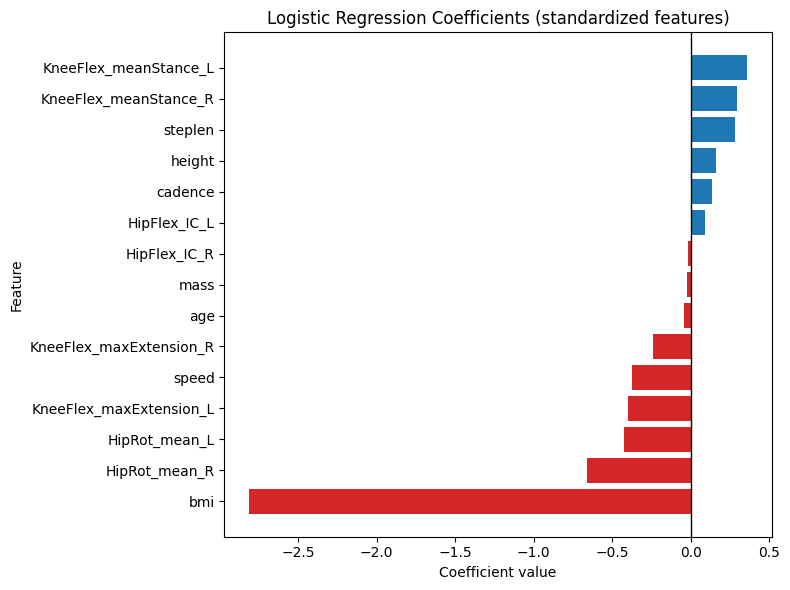

In [113]:
# Plot logistic-regression coefficients by feature
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values("coefficient")

plt.figure(figsize=(8, 6))
colors = coef_df["coefficient"].apply(lambda v: "tab:red" if v < 0 else "tab:blue")
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients (standardized features)")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Why do we need hyperparameter tuning?

Most machine-learning models have settings called **hyperparameters** that control how the model learns from the data.  
Examples include:

- the depth of a decision tree  
- the number of trees in a random forest  
- the number of neighbors in k-nearest neighbors  
- the regularization strength in logistic regression  

These settings are **not learned automatically** during training — they must be chosen by the user.

---

### Why does this matter?

Different hyperparameter values can lead to very different model behavior.

For example:

- a very deep decision tree may **overfit** the training data  
- a very shallow tree may **underfit** and miss important patterns  
- too few neighbors in kNN can make predictions very noisy  
- too many neighbors can make the model too rigid  

Because of this, choosing hyperparameters carefully helps us find a model that:

---

### How do we tune hyperparameters?

A common approach is to:

1. Try multiple combinations of hyperparameter values  
2. Evaluate each combination using **cross-validation** on the training data  
3. Select the combination that gives the best performance metric (for example, ROC AUC)

This process is called **hyperparameter tuning** or **model selection**.



In [115]:
param_grid_linear = [
    {'penalty': ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['saga'], "class_weight": [None, "balanced"]},
]

model = LogisticRegression(random_state=0, max_iter=10000)
scaler = StandardScaler()
scaler.fit(X_train)


#cross-validation with grouping by subject to avoid data leakage between train and test folds
cv = GroupKFold(n_splits=5) 

#search all combinations of hyperparameters in param_grid_linear using cross-validation with grouping by subject, 
#and evaluate the models using ROC AUC score
grid_search = GridSearchCV(estimator=model, param_grid=param_grid_linear, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_search.fit(scaler.transform(X_train), y_train, groups=groups_train)

#print the best hyperparameters found by grid search, and evaluate the best model on the test set
print("Best hyperparameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(scaler.transform(X_test))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)


Best hyperparameters: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
              precision    recall  f1-score   support

           0       0.72      0.69      0.70       807
           1       0.65      0.69      0.67       680

    accuracy                           0.69      1487
   macro avg       0.69      0.69      0.69      1487
weighted avg       0.69      0.69      0.69      1487



In [117]:
#lest do the same thing with a random forest classifier, and compare the results to logistic regression
from sklearn.ensemble import RandomForestClassifier
param_grid_rf = [
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2, 4],
            "class_weight": [None, "balanced"]
        }
]

model_rf = RandomForestClassifier(random_state=0)
grid_search_rf = GridSearchCV(estimator=model_rf, param_grid=param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_search_rf.fit(X_train, y_train, groups=groups_train)
print("Best hyperparameters (RF):", grid_search_rf.best_params_)
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)



Best hyperparameters (RF): {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.69      0.70      0.70       807
           1       0.64      0.63      0.64       680

    accuracy                           0.67      1487
   macro avg       0.67      0.67      0.67      1487
weighted avg       0.67      0.67      0.67      1487



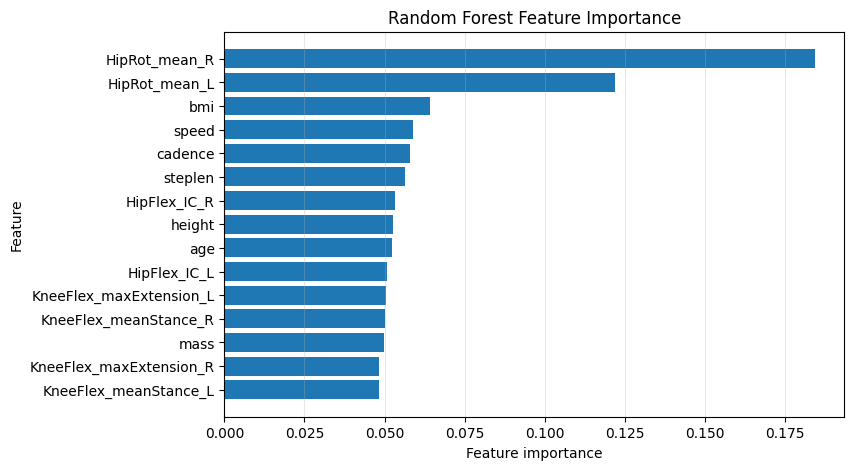

In [118]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

# %%
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

In [122]:
selected_features = importance_df[importance_df["Importance"] > 0.05]["Feature"].tolist()
param_grid_rf = [
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2, 4],
            "class_weight": [None, "balanced"]
        }
]

#re-run the random forest model using only the selected features, and compare the results to the previous models
X_select = model_df[selected_features]
y = model_df["target"].values
groups = model_df["Patient_ID"].values

#create a train-test split using GroupShuffleSplit to ensure that all samples from the same subject are in the same set
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
train_idx, test_idx = next(gss.split(X_select, y, groups=groups))

#split the data into training and testing sets based on the indices from GroupShuffleSplit
X_train_select = X_select.iloc[train_idx].reset_index(drop=True)
X_test_select = X_select.iloc[test_idx].reset_index(drop=True)
y_train = y[train_idx]
y_test = y[test_idx]
groups_train = groups[train_idx]
groups_test = groups[test_idx]

model_rf_select = RandomForestClassifier(random_state=0)
grid_search_rf_select = GridSearchCV(estimator=model_rf_select, param_grid=param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_search_rf_select.fit(X_train_select, y_train, groups=groups_train)
print("Best hyperparameters (RF):", grid_search_rf_select.best_params_)
best_rf_select = grid_search_rf_select.best_estimator_
y_pred_rf = best_rf_select.predict(X_test_select)
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)

Best hyperparameters (RF): {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.68      0.74      0.71       807
           1       0.65      0.58      0.62       680

    accuracy                           0.67      1487
   macro avg       0.67      0.66      0.66      1487
weighted avg       0.67      0.67      0.67      1487



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Generate ROC curves and calculate AUC scores for all three models

# Get predictions for all three models
y_pred_proba_lr = best_model.predict_proba(scaler.transform(X_test))[:, 1]
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_proba_rf_select = best_rf_select.predict_proba(X_test_select)[:, 1]

# Calculate ROC curves and AUC scores
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_rf_select, tpr_rf_select, _ = roc_curve(y_test, y_pred_proba_rf_select)

auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
auc_rf_select = roc_auc_score(y_test, y_pred_proba_rf_select)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot(fpr_rf_select, tpr_rf_select, label=f'Random Forest Selected Features (AUC = {auc_rf_select:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Print AUC scores
print(f"Logistic Regression AUC: {auc_lr:.3f}")
print(f"Random Forest AUC: {auc_rf:.3f}")
print(f"Random Forest (Selected Features) AUC: {auc_rf_select:.3f}")